# Exploratory Analysis of Global Train Accidents (2000–2024)

This notebook provides a basic exploratory data analysis (EDA) of global train accident data
covering the period from 2000 to 2024. The goal is to understand accident patterns, causes,
severity, and high-risk categories.

In [184]:
# Import the pandas library and load dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "C:\\Users\\mehfo\\Downloads\\rail_accident.csv",
   on_bad_lines='skip'

)
df.head()

,accident_id,date,country,location,continent,train_type,accident_type,cause,deaths,injured,hazmat_involved,notes
0,A2000_01,2000-01-04,Norway,Åsta,Europe,Passenger,Collision,Human error,19,NaN,False,Head-on collision
1,A2000_02,2000-02-06,Germany,Brühl,Europe,Passenger,Derailment,Human error,9,NaN,False,Overspeed through turnout
2,A2000_03,2000-03-02,Denmark,Kolkær,Europe,Passenger,Collision,Human error,3,10.0,False,Signal passed at danger
3,A2000_04,2000-03-08,Japan,Naka-Meguro,Asia,Metro,Derailment,Signal failure,5,63.0,False,Derailment then collision
4,A2000_05,2000-03-28,United States,Tennga Georgia,North America,Freight,Collision,Human error,3,NaN,False,School bus at crossing


In [185]:
import os
os.chdir(r"C:\Users\mehfo\Downloads")
os.getcwd()

'C:\\Users\\mehfo\\Downloads'

In [186]:
#Check for missing (null)
df.isnull().sum()

accident_id         0
date                0
country             0
location            0
continent           0
train_type          0
accident_type       0
cause               0
deaths              0
injured            19
hazmat_involved     0
notes               0
dtype: int64

In [187]:
#Check for total duplicate rows
df.duplicated().sum()


0

In [188]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['accident_id', 'date', 'country', 'location', 'continent', 'train_type',
       'accident_type', 'cause', 'deaths', 'injured', 'hazmat_involved',
       'notes'],
      dtype='object')

In [189]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['deaths'] = pd.to_numeric(df['deaths'], errors='coerce')
df['injured'] = pd.to_numeric(df['injured'], errors='coerce')
df['hazmat_involved'] = df['hazmat_involved'].astype(bool)

In [190]:
df['injured'] = df['injured'].fillna(0)

In [191]:
df = df.rename(columns={'notes': 'incident_summary'})

In [192]:
df['year'] = df['date'].dt.year

In [193]:
df['severity_score'] = df['deaths'] * 5 + df['injured']

In [194]:
df['location'] = df['location'].str.title()

In [195]:
df['year'] = pd.to_datetime(df['date']).dt.year
df['decade'] = (df['year'] // 10) * 10

In [196]:
def severity_level(x):
    if x < 20:
        return "Low"
    elif x < 60:
        return "Medium"
    elif x < 120:
        return "High"
    else:
        return "Extreme"

df['severity_level'] = df['severity_score'].apply(severity_level)

In [197]:
df['casualty_type'] = df.apply(
    lambda x: "Fatal" if x['deaths'] > 0 else "Non-fatal",
    axis=1
)

In [198]:
df['country'].value_counts().head(10)

country
United States     101
India              69
Germany            18
China              15
South Africa       13
United Kingdom     13
Canada             12
Italy              12
Egypt              11
Spain              11
Name: count, dtype: int64

In [199]:
df.groupby('train_type')['severity_score'].mean()

train_type
Freight         78.921053
Heritage        10.000000
High Speed      38.666667
High-speed     268.250000
Light Rail      70.000000
Maintenance     10.000000
Metro           62.695652
Mixed          126.666667
Passenger      153.162362
Tram            71.000000
Name: severity_score, dtype: float64

In [200]:
df.columns

Index(['accident_id', 'date', 'country', 'location', 'continent', 'train_type',
       'accident_type', 'cause', 'deaths', 'injured', 'hazmat_involved',
       'incident_summary', 'year', 'severity_score', 'decade',
       'severity_level', 'casualty_type'],
      dtype='object')

In [201]:
def generalize_cause(cause):
    cause = str(cause).lower().strip()

    if cause in ["human error", "overspeeding"]:
        return "Human Error"

    elif cause in ["mechanical failure", "electrical failure"]:
        return "Technical Failure"

    elif cause in [
        "track failure",
        "signal failure",
        "signal software bug",
        "infrastructure failure"
    ]:
        return "Infrastructure Failure"

    elif cause in [
        "weather",
        "landslide",
        "natural disaster",
        "natural obstruction",
        "animal on track"
    ]:
        return "Environmental / Natural"

    else:
        return "External / Other"
df["cause_category"] = df["cause"].apply(generalize_cause)

In [202]:
df["cause_category"].value_counts()

cause_category
Infrastructure Failure     172
Human Error                151
Technical Failure           54
Environmental / Natural     23
External / Other            12
Name: count, dtype: int64

In [203]:
df.head()

,accident_id,date,country,location,continent,train_type,accident_type,cause,deaths,injured,hazmat_involved,incident_summary,year,severity_score,decade,severity_level,casualty_type,cause_category
0,A2000_01,2000-01-04,Norway,Åsta,Europe,Passenger,Collision,Human error,19,0.0,False,Head-on collision,2000,95.0,2000,High,Fatal,Human Error
1,A2000_02,2000-02-06,Germany,Brühl,Europe,Passenger,Derailment,Human error,9,0.0,False,Overspeed through turnout,2000,45.0,2000,Medium,Fatal,Human Error
2,A2000_03,2000-03-02,Denmark,Kolkær,Europe,Passenger,Collision,Human error,3,10.0,False,Signal passed at danger,2000,25.0,2000,Medium,Fatal,Human Error
3,A2000_04,2000-03-08,Japan,Naka-Meguro,Asia,Metro,Derailment,Signal failure,5,63.0,False,Derailment then collision,2000,88.0,2000,High,Fatal,Infrastructure Failure
4,A2000_05,2000-03-28,United States,Tennga Georgia,North America,Freight,Collision,Human error,3,0.0,False,School bus at crossing,2000,15.0,2000,Low,Fatal,Human Error


In [204]:
bins = [2000, 2005, 2010, 2015, 2020, 2025]
labels = [
    "2000–2004",
    "2005–2009",
    "2010–2014",
    "2015–2019",
    "2020–2024"
]

df['year_interval'] = pd.cut(df['year'], bins=bins, labels=labels, right=False)

In [205]:
df.drop(columns=["cause"], inplace=True)


In [206]:
df['accident_id'] = range(1, len(df) + 1)


In [207]:
df['date'] = pd.to_datetime(df['date'])

In [208]:
df['injured'] = df['injured'].astype(int)

In [215]:
df = df[[
    'accident_id',
    'date',
    'year',
    'decade',
    'year_interval',
    'country',
    'continent',
    'train_type',
    'accident_type',
    'cause_category',
    'deaths',
    'injured',
    'hazmat_involved',
    'severity_score',
    'severity_level',
    'casualty_type',
    'incident_summary'
]]

In [216]:
df.describe()

,accident_id,date,year,decade,deaths,injured,severity_score
count,412.000000,412,412.000000,412.000000,412.000000,412.000000,412.000000
mean,206.500000,2015-03-06 08:51:15.728155392,2014.740291,2010.800971,14.837379,53.582524,127.769417
min,1.000000,2000-01-04 00:00:00,2000.000000,2000.000000,0.000000,0.000000,0.000000
25%,103.750000,2011-05-23 00:00:00,2011.000000,2010.000000,0.000000,2.000000,7.000000
50%,206.500000,2016-05-21 00:00:00,2016.000000,2010.000000,0.500000,18.000000,27.000000
75%,309.250000,2020-03-27 18:00:00,2020.000000,2020.000000,6.000000,47.250000,95.000000
max,412.000000,2024-11-15 00:00:00,2024.000000,2020.000000,1700.000000,2500.000000,8500.000000
std,119.078406,NaN,6.451242,6.947085,90.368482,158.488666,495.932264


In [217]:
df = df.copy()

In [218]:
# Standardize casing
df['train_type'] = df['train_type'].str.strip().str.title()

# Normalize names
df['train_type'] = df['train_type'].replace({
    'Freight': 'Cargo',
    'High Speed': 'High-Speed',
    'Tram': 'Metro',
    'Light Rail': 'Metro',
    'Heritage': 'Other',
    'Maintenance': 'Other',
     'Metro / Urban': 'Metro',
    'Other / Special': 'Other'
})

# Ensure categorical
df['train_type'] = df['train_type'].astype('category')


In [219]:
df["train_type"].value_counts()

train_type
Passenger     271
Cargo          76
Metro          50
High-Speed      7
Mixed           6
Other           2
Name: count, dtype: int64

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   accident_id       412 non-null    int64         
 1   date              412 non-null    datetime64[ns]
 2   year              412 non-null    int32         
 3   decade            412 non-null    int32         
 4   year_interval     412 non-null    category      
 5   country           412 non-null    object        
 6   continent         412 non-null    object        
 7   train_type        412 non-null    category      
 8   accident_type     412 non-null    object        
 9   cause_category    412 non-null    object        
 10  deaths            412 non-null    int64         
 11  injured           412 non-null    int32         
 12  hazmat_involved   412 non-null    bool          
 13  severity_score    412 non-null    float64       
 14  severity_level    412 non-

In [221]:
df[col] = df[col].astype('category')

In [222]:
categorical_cols = [
    'year_interval',
    'country',
    'continent',
    'train_type',
    'accident_type',
    'cause_category',
    'severity_level',
    'casualty_type'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [223]:
df.columns

Index(['accident_id', 'date', 'year', 'decade', 'year_interval', 'country',
       'continent', 'train_type', 'accident_type', 'cause_category', 'deaths',
       'injured', 'hazmat_involved', 'severity_score', 'severity_level',
       'casualty_type', 'incident_summary'],
      dtype='object')

In [224]:
df['accident_type'] = df['accident_type'].replace({
    'Fire': 'Fire/Explosion'
})

In [225]:
df['accident_type'] = df['accident_type'].replace({
    'Explosion': 'Fire/Explosion'
})

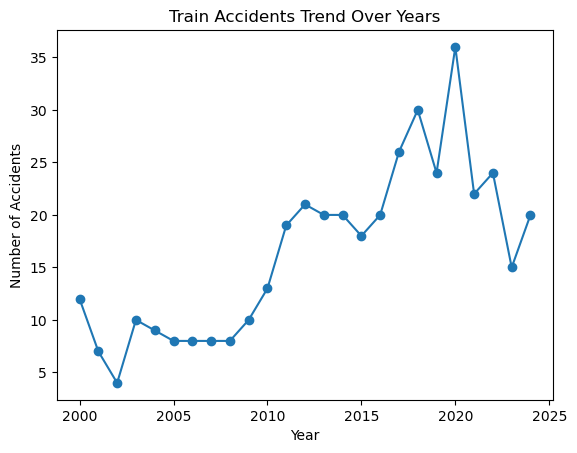

In [226]:
import matplotlib.pyplot as plt

trend = df.groupby('year')['accident_id'].count()

trend.plot(kind='line', marker='o')
plt.title("Train Accidents Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

# visualization

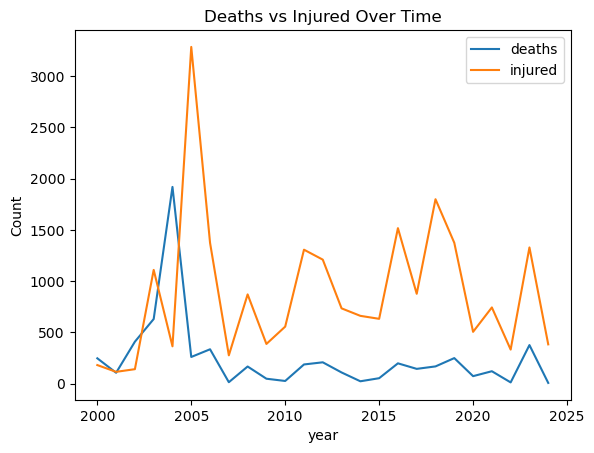

In [227]:
casualties = df.groupby('year')[['deaths', 'injured']].sum()

casualties.plot()
plt.title("Deaths vs Injured Over Time")
plt.ylabel("Count")
plt.show()

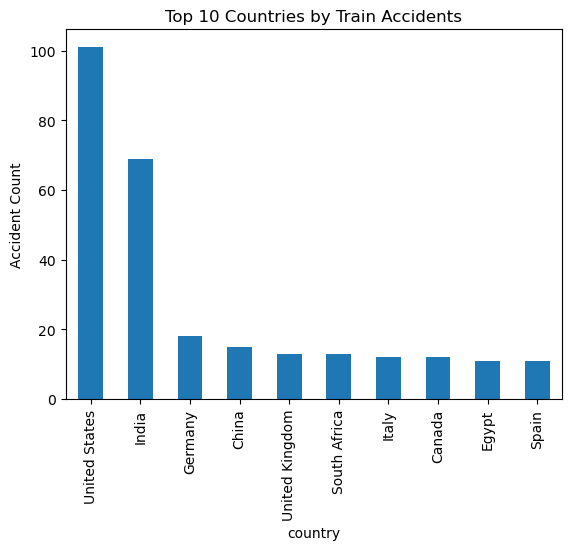

In [228]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Train Accidents")
plt.ylabel("Accident Count")
plt.show()

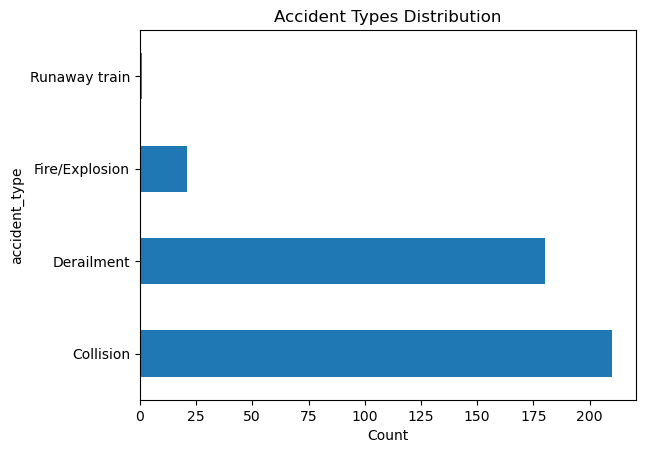

In [229]:
df['accident_type'].value_counts().plot(kind='barh')
plt.title("Accident Types Distribution")
plt.xlabel("Count")
plt.show()

In [232]:
df.to_csv("Global_train_accident_cleaned.csv", index=False)


## Conclusion

This exploratory analysis highlights several critical insights from global train accident data between 2000 and 2024. 
Accidents are not evenly distributed over time or causes, with infrastructure failure and human error emerging as dominant risk factors.
Passenger trains account for the highest number of incidents, while derailments result in the most severe outcomes in terms of fatalities.

The findings emphasize the need for targeted safety interventions, improved infrastructure maintenance, and better human-factor risk mitigation.
This dataset can support further predictive modeling and risk assessment studies in railway safety.
